# QASPER — Complete Dense Retrieval + FAISS Benchmark

## This notebook is the full experiment

**Nothing in the FAISS parameter sweeps is optional.**

The notebook evaluates:

### Embedding models
- BGE: `BAAI/bge-base-en-v1.5`
- E5: `intfloat/e5-base-v2`

### FAISS methods
- FlatIP — exact reference
- HNSW — full `M × efSearch` sweep
- IVF-Flat — full `nlist × nprobe` sweep
- IVF-PQ — full `nlist × nprobe` sweep

### Required evaluation
For K = `1, 3, 5, 10, 20, 50`:

- Precision@K
- Recall@K
- F1@K
- Hit@K
- nDCG@K

Also:

- MRR
- MAP
- ANN Recall@K versus exact FlatIP
- mean search latency
- p50 search latency
- p95 search latency
- p99 search latency
- build/training time
- index size
- embedding time

---

## Exact dataset paths

```text
/kaggle/input/datasets/arvindnandigam/qasper-dataset/data/qasper/answers
/kaggle/input/datasets/arvindnandigam/qasper-dataset/data/qasper/corpus
/kaggle/input/datasets/arvindnandigam/qasper-dataset/data/qasper/qrels
/kaggle/input/datasets/arvindnandigam/qasper-dataset/data/qasper/queries
```

The corpus is already chunked. We do **not** perform another chunking step.

Known sizes:

```text
Corpus : 81,550
Queries: 1,310
Qrels  : 3,434
Answers: 1,310
```

---

# Experiment matrix

## HNSW

```text
M         = {16, 32, 64}
efSearch  = {32, 64, 128, 256}
```

**12 configurations per model.**

## IVF-Flat

```text
nlist  = {64, 128, 256, 512}
nprobe = {4, 8, 16, 32, 64}
```

**20 configurations per model.**

## IVF-PQ

```text
nlist  = {64, 128, 256, 512}
nprobe = {4, 8, 16, 32, 64}
pq_m   = 48
pq_bits = 8
```

**20 configurations per model.**

Therefore, for two models, the mandatory ANN sweep contains:

```text
24 HNSW
40 IVF
40 IVF-PQ
----------------
104 approximate-index configurations
```

plus:

```text
2 FlatIP exact references
```

for **106 configurations total**.

The Transformer embeddings are cached once per model and reused by every index.

In [1]:
# ============================================================
# 1. Kaggle installation
# ============================================================
# IMPORTANT:
# Do not upgrade NumPy/Pandas in Kaggle's preconfigured runtime.

!pip -q install transformers huggingface_hub faiss-cpu tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 53.0 MB/s eta 0:00:0000:01:00:01


In [2]:
# ============================================================
# 2. Imports, GPU check, and paths
# ============================================================

import gc
import json
import math
import time
from pathlib import Path

import faiss
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel

print("PyTorch:", torch.__version__)
print("FAISS:", faiss.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA devices:", torch.cuda.device_count())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. In Kaggle select GPU → T4 x2."
    )

for gpu_id in range(torch.cuda.device_count()):
    print(
        f"GPU {gpu_id}:",
        torch.cuda.get_device_name(gpu_id)
    )

DATA_ROOT = Path(
    "/kaggle/input/datasets/arvindnandigam/qasper-dataset/data/qasper"
)

CORPUS_PATH = DATA_ROOT / "corpus" / "corpus.parquet"
QUERIES_PATH = DATA_ROOT / "queries" / "test.parquet"
QRELS_PATH = DATA_ROOT / "qrels" / "test.parquet"
ANSWERS_PATH = DATA_ROOT / "answers" / "test.parquet"

WORK_DIR = Path("/kaggle/working/qasper_dense_full")
EMBED_DIR = WORK_DIR / "embeddings"
INDEX_DIR = WORK_DIR / "indexes"
RESULT_DIR = WORK_DIR / "results"

for directory in [
    WORK_DIR,
    EMBED_DIR,
    INDEX_DIR,
    RESULT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

for path_obj in [
    CORPUS_PATH,
    QUERIES_PATH,
    QRELS_PATH,
    ANSWERS_PATH,
]:
    if not path_obj.exists():
        raise FileNotFoundError(
            f"Missing dataset file: {path_obj}"
        )

print("\nDataset files verified.")

PyTorch: 2.10.0+cu128
FAISS: 1.15.0
CUDA available: True
CUDA devices: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Dataset files verified.


# 3. Load QASPER

The qrels are the retrieval ground truth.

A qrel:

```text
(query_id, corpus_id, score=1)
```

means that the corpus chunk is relevant to that query.

We therefore build:

```text
query_id → {relevant corpus IDs}
```

In [3]:
# ============================================================
# 3. Load and validate
# ============================================================

corpus = pd.read_parquet(CORPUS_PATH)
queries = pd.read_parquet(QUERIES_PATH)
qrels_df = pd.read_parquet(QRELS_PATH)
answers = pd.read_parquet(ANSWERS_PATH)

corpus["id"] = corpus["id"].astype(str)
queries["id"] = queries["id"].astype(str)
qrels_df["query_id"] = qrels_df["query_id"].astype(str)
qrels_df["corpus_id"] = qrels_df["corpus_id"].astype(str)

qrels = (
    qrels_df
    .groupby("query_id")["corpus_id"]
    .apply(set)
    .to_dict()
)

print("=" * 70)
print("QASPER DATASET")
print("=" * 70)
print("Corpus :", f"{len(corpus):,}")
print("Queries:", f"{len(queries):,}")
print("Qrels  :", f"{len(qrels_df):,}")
print("Answers:", f"{len(answers):,}")

gold_counts = queries["id"].map(
    lambda qid: len(qrels.get(qid, set()))
)

print("\nGold chunks/query:")
print("Minimum:", gold_counts.min())
print("Mean   :", round(gold_counts.mean(), 3))
print("Median :", gold_counts.median())
print("Maximum:", gold_counts.max())

assert len(corpus) == 81550
assert len(queries) == 1310
assert len(qrels_df) == 3434
assert len(answers) == 1310

assert queries["id"].isin(qrels.keys()).all()
assert qrels_df["corpus_id"].isin(
    set(corpus["id"])
).all()

print("\nDataset validation: PASSED")

QASPER DATASET
Corpus : 81,550
Queries: 1,310
Qrels  : 3,434
Answers: 1,310

Gold chunks/query:
Minimum: 1
Mean   : 2.621
Median : 2.0
Maximum: 67

Dataset validation: PASSED


# 4. Inspect the retrieval ground truth

This confirms what is being measured.

The LLM-generated answer is **not** used as retrieval ground truth.

For retrieval evaluation, qrels tell us which corpus chunks are relevant.

The answers are retained for the later RAG/LLM evaluation stage.

In [4]:
# ============================================================
# 4. Inspect one question and gold evidence
# ============================================================

qid = queries.iloc[0]["id"]

print("QUERY ID:")
print(qid)

print("\nQUESTION:")
print(queries.iloc[0]["text"])

print("\nGOLD CHUNKS:")

for corpus_id in qrels[qid]:
    row = corpus[
        corpus["id"] == corpus_id
    ].iloc[0]

    print("-" * 70)
    print("ID:", row["id"])
    print("TITLE:", row["title"])
    print("SECTION:", row["section_name"])
    print("TEXT:")
    print(row["text"][:1500])

QUERY ID:
397a1e851aab41c455c2b284f5e4947500d797f0

QUESTION:
How big is the ANTISCAM dataset? 

GOLD CHUNKS:
----------------------------------------------------------------------
ID: 1911.10742_00015
TITLE: End-to-End Trainable Non-Collaborative Dialog System
SECTION: Datasets ::: AntiScam Dataset
TEXT:
To enrich available non-collaborative task datasets, we created a corpus of human-human anti-scam dialogs in order to learn human elicitation strategies. We chose a popular Amazon customer service scam scenario to collect dialogs between users and attackers who aim to collect users information. We posted a role-playing task on the Amazon Mechanical Turk platform and collected a typing conversation dataset named AntiScam. We collected 220 human-human dialogs. The average conversation length is 12.45 turns and the average utterance length is 11.13 words. Only 172 out of 220 users successfully identified their partner as an attacker, suggesting that the attackers are well trained and not

# 5. Embedding models

We directly use Hugging Face Transformers.

Pipeline:

```text
Text
 ↓
Tokenizer
 ↓
Transformer
 ↓
Hidden states
 ↓
Attention-mask mean pooling
 ↓
L2 normalization
 ↓
Vector
```

The resulting vectors are normalized, so:

```text
inner product = cosine similarity
```

for FAISS retrieval.

### BGE

Uses a retrieval-specific query instruction.

### E5

Uses:

```text
query: ...
passage: ...
```

prefixes.

In [5]:
MODELS = {
    "bge": {
        "name": "BAAI/bge-base-en-v1.5",
        "query_prefix": (
            "Represent this sentence for searching relevant passages: "
        ),
        "passage_prefix": "",
    },
    "e5": {
        "name": "intfloat/e5-base-v2",
        "query_prefix": "query: ",
        "passage_prefix": "passage: ",
    },
}

DEVICE = torch.device("cuda")

# If T4 memory is insufficient, change 64 → 32 → 16.
BATCH_SIZE = 64

MAX_LENGTH = 512

K_VALUES = [
    1,
    3,
    5,
    10,
    20,
    50,
]

MAX_K = max(K_VALUES)

print("Models:")
for key, cfg in MODELS.items():
    print(key, "→", cfg["name"])

print("\nBatch size:", BATCH_SIZE)
print("Max length:", MAX_LENGTH)

Models:
bge → BAAI/bge-base-en-v1.5
e5 → intfloat/e5-base-v2

Batch size: 64
Max length: 512


# 6. Hugging Face encoder

In [6]:
class HFEncoder:
    def __init__(
        self,
        model_name,
        max_length=512,
    ):
        self.model_name = model_name
        self.max_length = max_length

        print("Tokenizer:", model_name)

        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name
        )

        print("Model:", model_name)

        self.model = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
        ).to(DEVICE)

        self.model.eval()

        self.dimension = int(
            self.model.config.hidden_size
        )

        print(
            "Dimension:",
            self.dimension
        )

    @staticmethod
    def mean_pool(
        hidden_states,
        attention_mask,
    ):
        mask = attention_mask.unsqueeze(-1).expand(
            hidden_states.size()
        ).float()

        summed = (
            hidden_states * mask
        ).sum(dim=1)

        counts = mask.sum(
            dim=1
        ).clamp(min=1e-9)

        return summed / counts

    @torch.inference_mode()
    def encode(
        self,
        texts,
        prefix="",
        batch_size=64,
    ):
        embeddings = []

        start = time.perf_counter()

        for i in tqdm(
            range(
                0,
                len(texts),
                batch_size,
            ),
            desc="Encoding",
        ):
            batch = [
                prefix + str(x)
                for x in texts[
                    i:i + batch_size
                ]
            ]

            tokens = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt",
            )

            tokens = {
                key: value.to(DEVICE)
                for key, value in tokens.items()
            }

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
            ):
                output = self.model(
                    **tokens
                )

            pooled = self.mean_pool(
                output.last_hidden_state,
                tokens["attention_mask"],
            )

            pooled = torch.nn.functional.normalize(
                pooled,
                p=2,
                dim=1,
            )

            embeddings.append(
                pooled
                .float()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

        elapsed = (
            time.perf_counter()
            - start
        )

        return (
            np.vstack(embeddings),
            elapsed,
        )


def normalize_embeddings(
    embeddings,
):
    x = np.asarray(
        embeddings,
        dtype=np.float32,
    ).copy()

    faiss.normalize_L2(x)

    return x


def encode_cached(
    encoder,
    texts,
    prefix,
    path_obj,
):
    path_obj.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if path_obj.exists():
        print(
            "Loading cached:",
            path_obj,
        )

        arr = np.load(
            path_obj,
            mmap_mode="r",
        )

        return (
            np.asarray(
                arr,
                dtype=np.float32,
            ),
            0.0,
            True,
        )

    embeddings, elapsed = encoder.encode(
        texts,
        prefix=prefix,
        batch_size=BATCH_SIZE,
    )

    np.save(
        path_obj,
        embeddings,
    )

    print(
        "Saved:",
        path_obj,
        "| shape:",
        embeddings.shape,
        "| size:",
        f"{embeddings.nbytes / 1024**3:.2f} GB",
    )

    return (
        embeddings,
        elapsed,
        False,
    )

# 7. Encode and cache BGE + E5

This is the expensive Transformer stage.

It happens only once per model.

After this cell:

```text
BGE corpus vectors  → cached
BGE query vectors   → cached
E5 corpus vectors   → cached
E5 query vectors    → cached
```

All 106 FAISS experiments reuse these vectors.

In [7]:
# ============================================================
# 7. Encode/cache both models
# ============================================================

CORPUS_TEXTS = (
    corpus["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

QUERY_TEXTS = (
    queries["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

EMBED_CACHE = {}

for model_key, cfg in MODELS.items():

    print("\n" + "=" * 80)
    print("ENCODING:", model_key.upper())
    print("=" * 80)

    encoder = HFEncoder(
        cfg["name"],
        max_length=MAX_LENGTH,
    )

    corpus_path = (
        EMBED_DIR
        / model_key
        / "corpus.npy"
    )

    query_path = (
        EMBED_DIR
        / model_key
        / "queries_test.npy"
    )

    corpus_emb, corpus_sec, corpus_cached = (
        encode_cached(
            encoder,
            CORPUS_TEXTS,
            cfg["passage_prefix"],
            corpus_path,
        )
    )

    query_emb, query_sec, query_cached = (
        encode_cached(
            encoder,
            QUERY_TEXTS,
            cfg["query_prefix"],
            query_path,
        )
    )

    corpus_emb = normalize_embeddings(
        corpus_emb
    )

    query_emb = normalize_embeddings(
        query_emb
    )

    EMBED_CACHE[model_key] = {
        "corpus": corpus_emb,
        "queries": query_emb,
        "corpus_encode_sec": corpus_sec,
        "query_encode_sec": query_sec,
        "corpus_cached": corpus_cached,
        "query_cached": query_cached,
        "dimension": int(
            corpus_emb.shape[1]
        ),
    }

    print(
        "Corpus vectors:",
        corpus_emb.shape,
    )

    print(
        "Query vectors:",
        query_emb.shape,
    )

    del encoder
    gc.collect()
    torch.cuda.empty_cache()


ENCODING: BGE
Tokenizer: BAAI/bge-base-en-v1.5


config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Dimension: 768


Encoding:   0%|          | 0/1275 [00:00<?, ?it/s]

Saved: /kaggle/working/qasper_dense_full/embeddings/e5/corpus.npy | shape: (81550, 768) | size: 0.23 GB


Encoding:   0%|          | 0/21 [00:00<?, ?it/s]

Saved: /kaggle/working/qasper_dense_full/embeddings/e5/queries_test.npy | shape: (1310, 768) | size: 0.00 GB
Corpus vectors: (81550, 768)
Query vectors: (1310, 768)


# 8. Retrieval evaluation metrics

For every query:

```text
G = gold qrel chunks
R_K = retrieved top-K chunks
```

## Precision@K

Fraction of retrieved chunks that are relevant.

## Recall@K

Fraction of all gold chunks retrieved.

This is especially important for our later context-selection/RL system.

## F1@K

Harmonic mean of precision and recall.

## Hit@K

Whether at least one relevant chunk appears.

## nDCG@K

Rewards relevant chunks appearing earlier in the ranking.

## MRR

Measures the rank of the first relevant chunk.

## MAP

Measures ranking quality across multiple relevant chunks.

## ANN Recall@K

For approximate FAISS methods only:

```text
approximate top-K ∩ exact top-K
--------------------------------
        exact top-K
```

This measures approximation error, not QASPER evidence coverage.

In [8]:
def precision_at_k(
    retrieved,
    relevant,
    k,
):
    return (
        sum(
            doc in relevant
            for doc in retrieved[:k]
        )
        / k
    )


def recall_at_k(
    retrieved,
    relevant,
    k,
):
    if not relevant:
        return 0.0

    return (
        sum(
            doc in relevant
            for doc in retrieved[:k]
        )
        / len(relevant)
    )


def f1_at_k(
    retrieved,
    relevant,
    k,
):
    precision = precision_at_k(
        retrieved,
        relevant,
        k,
    )

    recall = recall_at_k(
        retrieved,
        relevant,
        k,
    )

    if precision + recall == 0:
        return 0.0

    return (
        2
        * precision
        * recall
        / (precision + recall)
    )


def hit_at_k(
    retrieved,
    relevant,
    k,
):
    return float(
        any(
            doc in relevant
            for doc in retrieved[:k]
        )
    )


def ndcg_at_k(
    retrieved,
    relevant,
    k,
):
    if not relevant:
        return 0.0

    dcg = 0.0

    for rank, doc in enumerate(
        retrieved[:k],
        start=1,
    ):
        if doc in relevant:
            dcg += (
                1.0
                / np.log2(rank + 1)
            )

    ideal_hits = min(
        k,
        len(relevant),
    )

    idcg = sum(
        1.0
        / np.log2(rank + 1)
        for rank in range(
            1,
            ideal_hits + 1,
        )
    )

    return (
        dcg / idcg
        if idcg
        else 0.0
    )


def reciprocal_rank(
    retrieved,
    relevant,
):
    for rank, doc in enumerate(
        retrieved,
        start=1,
    ):
        if doc in relevant:
            return 1.0 / rank

    return 0.0


def average_precision(
    retrieved,
    relevant,
):
    if not relevant:
        return 0.0

    hits = 0
    total = 0.0

    for rank, doc in enumerate(
        retrieved,
        start=1,
    ):
        if doc in relevant:
            hits += 1
            total += hits / rank

    return (
        total / len(relevant)
    )


def ann_recall_at_k(
    approximate,
    exact,
    k,
):
    exact_set = set(
        exact[:k]
    )

    approximate_set = set(
        approximate[:k]
    )

    if not exact_set:
        return 0.0

    return (
        len(
            exact_set
            & approximate_set
        )
        / len(exact_set)
    )

# 9. FAISS index builders

## FlatIP

Exact inner-product search.

Because vectors are normalized:

```text
inner product = cosine similarity
```

FlatIP is the exact reference.

## HNSW

Graph-based ANN.

Parameters:

```text
M
efConstruction
efSearch
```

## IVF-Flat

Cluster-based ANN.

Parameters:

```text
nlist
nprobe
```

## IVF-PQ

IVF plus Product Quantization.

Parameters:

```text
nlist
nprobe
pq_m
pq_bits
```

In [9]:
def build_flat(
    embeddings,
):
    index = faiss.IndexFlatIP(
        embeddings.shape[1]
    )

    start = time.perf_counter()

    index.add(
        embeddings
    )

    build_sec = (
        time.perf_counter()
        - start
    )

    return index, {
        "index_type": "FlatIP",
        "build_sec": build_sec,
    }


def build_hnsw(
    embeddings,
    M,
    ef_construction=200,
    ef_search=32,
):
    index = faiss.IndexHNSWFlat(
        embeddings.shape[1],
        M,
        faiss.METRIC_INNER_PRODUCT,
    )

    index.hnsw.efConstruction = (
        ef_construction
    )

    index.hnsw.efSearch = (
        ef_search
    )

    start = time.perf_counter()

    index.add(
        embeddings
    )

    build_sec = (
        time.perf_counter()
        - start
    )

    return index, {
        "index_type": "HNSW",
        "M": M,
        "efConstruction": ef_construction,
        "efSearch": ef_search,
        "build_sec": build_sec,
    }


def build_ivf(
    embeddings,
    nlist,
    nprobe=4,
):
    d = embeddings.shape[1]

    quantizer = faiss.IndexFlatIP(d)

    index = faiss.IndexIVFFlat(
        quantizer,
        d,
        nlist,
        faiss.METRIC_INNER_PRODUCT,
    )

    start = time.perf_counter()

    index.train(
        embeddings
    )

    train_sec = (
        time.perf_counter()
        - start
    )

    index.nprobe = nprobe

    start = time.perf_counter()

    index.add(
        embeddings
    )

    add_sec = (
        time.perf_counter()
        - start
    )

    return index, {
        "index_type": "IVF-Flat",
        "nlist": nlist,
        "nprobe": nprobe,
        "train_sec": train_sec,
        "add_sec": add_sec,
        "build_sec": (
            train_sec
            + add_sec
        ),
    }


def build_ivfpq(
    embeddings,
    nlist,
    nprobe=4,
    pq_m=48,
    pq_bits=8,
):
    d = embeddings.shape[1]

    if d % pq_m != 0:
        raise ValueError(
            f"pq_m={pq_m} must divide "
            f"embedding dimension {d}"
        )

    quantizer = faiss.IndexFlatIP(d)

    index = faiss.IndexIVFPQ(
        quantizer,
        d,
        nlist,
        pq_m,
        pq_bits,
        faiss.METRIC_INNER_PRODUCT,
    )

    start = time.perf_counter()

    index.train(
        embeddings
    )

    train_sec = (
        time.perf_counter()
        - start
    )

    index.nprobe = nprobe

    start = time.perf_counter()

    index.add(
        embeddings
    )

    add_sec = (
        time.perf_counter()
        - start
    )

    return index, {
        "index_type": "IVF-PQ",
        "nlist": nlist,
        "nprobe": nprobe,
        "pq_m": pq_m,
        "pq_bits": pq_bits,
        "train_sec": train_sec,
        "add_sec": add_sec,
        "build_sec": (
            train_sec
            + add_sec
        ),
    }

# 10. Exact FlatIP reference

We compute the exact top-50 neighbors once per model.

These exact rankings are reused for every ANN Recall calculation.

This is essential: otherwise every ANN experiment would repeatedly pay the exact-search cost.

In [10]:
# ============================================================
# 10. Exact FlatIP top-50 reference
# ============================================================

CORPUS_IDS = corpus["id"].tolist()
QUERY_IDS = queries["id"].tolist()

EXACT_TOP_IDS = {}
EXACT_INDEX_SUMMARIES = {}

for model_key in MODELS:

    print(
        "\nCreating exact reference:",
        model_key.upper()
    )

    emb = EMBED_CACHE[
        model_key
    ]["corpus"]

    qemb = EMBED_CACHE[
        model_key
    ]["queries"]

    index, info = build_flat(
        emb
    )

    start = time.perf_counter()

    _, indices = index.search(
        qemb,
        MAX_K,
    )

    search_sec = (
        time.perf_counter()
        - start
    )

    EXACT_TOP_IDS[
        model_key
    ] = [
        [
            CORPUS_IDS[int(i)]
            for i in row
            if int(i) >= 0
        ]
        for row in indices
    ]

    EXACT_INDEX_SUMMARIES[
        model_key
    ] = {
        **info,
        "search_total_sec": search_sec,
        "search_mean_ms": (
            search_sec
            * 1000
            / len(qemb)
        ),
    }

    print(
        "Exact reference ready."
    )


Creating exact reference: BGE
Exact reference ready.

Creating exact reference: E5
Exact reference ready.


# 11. Generic evaluator

This function is used by every index configuration.

It guarantees that all methods are evaluated under the same:

- queries
- corpus
- qrels
- K values
- latency methodology
- metric definitions

In [11]:
def evaluate_index(
    model_key,
    index_label,
    index,
    exact_top_ids=None,
    config=None,
    index_info=None,
):
    qemb = EMBED_CACHE[
        model_key
    ]["queries"]

    retrieved_ids = []
    latency_ms = []

    for query_vector in tqdm(
        qemb,
        desc=f"{model_key.upper()} | {index_label}",
    ):
        q = query_vector.reshape(
            1,
            -1,
        )

        start = time.perf_counter()

        _, indices = index.search(
            q,
            MAX_K,
        )

        elapsed = (
            time.perf_counter()
            - start
        ) * 1000

        latency_ms.append(
            elapsed
        )

        retrieved_ids.append(
            [
                CORPUS_IDS[int(i)]
                for i in indices[0]
                if int(i) >= 0
            ]
        )

    rows = []

    for i, query_id in enumerate(
        QUERY_IDS
    ):
        retrieved = retrieved_ids[i]

        relevant = qrels.get(
            query_id,
            set(),
        )

        row = {
            "model": model_key,
            "index": index_label,
            "query_id": query_id,
            "num_gold_chunks": len(
                relevant
            ),
            "search_ms": latency_ms[i],
            "rr": reciprocal_rank(
                retrieved,
                relevant,
            ),
            "average_precision": average_precision(
                retrieved,
                relevant,
            ),
        }

        if config:
            row.update(config)

        for k in K_VALUES:
            row[
                f"precision@{k}"
            ] = precision_at_k(
                retrieved,
                relevant,
                k,
            )

            row[
                f"recall@{k}"
            ] = recall_at_k(
                retrieved,
                relevant,
                k,
            )

            row[
                f"f1@{k}"
            ] = f1_at_k(
                retrieved,
                relevant,
                k,
            )

            row[
                f"hit@{k}"
            ] = hit_at_k(
                retrieved,
                relevant,
                k,
            )

            row[
                f"ndcg@{k}"
            ] = ndcg_at_k(
                retrieved,
                relevant,
                k,
            )

            if exact_top_ids is not None:
                row[
                    f"ann_recall@{k}"
                ] = ann_recall_at_k(
                    retrieved,
                    exact_top_ids[i],
                    k,
                )

        rows.append(row)

    df = pd.DataFrame(
        rows
    )

    times = np.asarray(
        latency_ms,
        dtype=np.float64,
    )

    summary = {
        "model": model_key,
        "index": index_label,
        "config": config or {},
        "index_info": index_info or {},
        "metrics": {},
        "latency_ms": {
            "mean": float(
                np.mean(times)
            ),
            "p50": float(
                np.percentile(
                    times,
                    50,
                )
            ),
            "p95": float(
                np.percentile(
                    times,
                    95,
                )
            ),
            "p99": float(
                np.percentile(
                    times,
                    99,
                )
            ),
        },
    }

    for k in K_VALUES:
        for metric in [
            "precision",
            "recall",
            "f1",
            "hit",
            "ndcg",
        ]:
            summary[
                "metrics"
            ][
                f"{metric}@{k}"
            ] = float(
                df[
                    f"{metric}@{k}"
                ].mean()
            )

        if exact_top_ids is not None:
            summary[
                "metrics"
            ][
                f"ann_recall@{k}"
            ] = float(
                df[
                    f"ann_recall@{k}"
                ].mean()
            )

    summary[
        "metrics"
    ]["mrr"] = float(
        df["rr"].mean()
    )

    summary[
        "metrics"
    ]["map"] = float(
        df[
            "average_precision"
        ].mean()
    )

    return (
        df,
        summary,
    )


def save_experiment(
    df,
    summary,
    stem,
):
    csv_path = (
        RESULT_DIR
        / f"{stem}.csv"
    )

    json_path = (
        RESULT_DIR
        / f"{stem}_summary.json"
    )

    df.to_csv(
        csv_path,
        index=False,
    )

    json_path.write_text(
        json.dumps(
            summary,
            indent=2,
        ),
        encoding="utf-8",
    )

    return (
        csv_path,
        json_path,
    )

# 12. Run the two exact FlatIP baselines

These are mandatory.

They establish the dense retrieval quality for BGE and E5 before approximation.

In [12]:
# ============================================================
# 12. FlatIP — BGE + E5
# ============================================================

for model_key in MODELS:

    emb = EMBED_CACHE[
        model_key
    ]["corpus"]

    index, info = build_flat(
        emb
    )

    df, summary = evaluate_index(
        model_key=model_key,
        index_label="FlatIP",
        index=index,
        exact_top_ids=None,
        config={
            "method": "FlatIP",
        },
        index_info=info,
    )

    summary[
        "model_name"
    ] = MODELS[
        model_key
    ]["name"]

    summary[
        "embedding_dimension"
    ] = int(
        emb.shape[1]
    )

    summary[
        "index_size_mb"
    ] = None

    save_experiment(
        df,
        summary,
        f"{model_key}_flatip",
    )

    print(
        f"\n{model_key.upper()} FlatIP"
    )

    print(
        "Recall@10:",
        f"{summary['metrics']['recall@10']:.4f}"
    )

    print(
        "nDCG@10:",
        f"{summary['metrics']['ndcg@10']:.4f}"
    )

    print(
        "MRR:",
        f"{summary['metrics']['mrr']:.4f}"
    )

BGE | FlatIP:   0%|          | 0/1310 [00:00<?, ?it/s]


BGE FlatIP
Recall@10: 0.1318
nDCG@10: 0.0965
MRR: 0.1156


E5 | FlatIP:   0%|          | 0/1310 [00:00<?, ?it/s]


E5 FlatIP
Recall@10: 0.1366
nDCG@10: 0.0975
MRR: 0.1109


# 13. MANDATORY HNSW SWEEP

This is the sweep you specifically requested.

It is **not optional**.

We test:

```text
M = 16, 32, 64

efSearch = 32, 64, 128, 256
```

That gives:

```text
3 × 4 = 12 configurations per embedding model
```

and:

```text
24 HNSW configurations total
```

### Important optimization

For a fixed `M`, the HNSW graph is built **once**.

Then:

```text
efSearch=32
efSearch=64
efSearch=128
efSearch=256
```

are evaluated against the same graph.

So we do not rebuild the graph unnecessarily.

In [13]:
# ============================================================
# 13. FULL HNSW SWEEP — M × efSearch
# ============================================================

HNSW_M_VALUES = [
    16,
    32,
    64,
]

HNSW_EF_VALUES = [
    32,
    64,
    128,
    256,
]

HNSW_EF_CONSTRUCTION = 200

hnsw_summaries = []
hnsw_per_query = []

for model_key in MODELS:

    emb = EMBED_CACHE[
        model_key
    ]["corpus"]

    exact_ids = EXACT_TOP_IDS[
        model_key
    ]

    for M in HNSW_M_VALUES:

        print("\n" + "=" * 90)
        print(
            f"HNSW GRAPH: {model_key.upper()} | "
            f"M={M}"
        )
        print("=" * 90)

        index, build_info = build_hnsw(
            emb,
            M=M,
            ef_construction=HNSW_EF_CONSTRUCTION,
            ef_search=HNSW_EF_VALUES[0],
        )

        for ef_search in HNSW_EF_VALUES:

            index.hnsw.efSearch = (
                ef_search
            )

            label = (
                f"HNSW_M{M}"
                f"_efSearch{ef_search}"
            )

            config = {
                "method": "HNSW",
                "M": M,
                "efConstruction": (
                    HNSW_EF_CONSTRUCTION
                ),
                "efSearch": ef_search,
            }

            info = {
                **build_info,
                "efSearch": ef_search,
            }

            df, summary = evaluate_index(
                model_key=model_key,
                index_label=label,
                index=index,
                exact_top_ids=exact_ids,
                config=config,
                index_info=info,
            )

            summary[
                "model_name"
            ] = MODELS[
                model_key
            ]["name"]

            summary[
                "embedding_dimension"
            ] = int(
                emb.shape[1]
            )

            summary[
                "index_size_mb"
            ] = None

            hnsw_summaries.append(
                summary
            )

            hnsw_per_query.append(
                df
            )

            save_experiment(
                df,
                summary,
                f"{model_key}_{label}",
            )

            print(
                f"{label}: "
                f"Recall@10="
                f"{summary['metrics']['recall@10']:.4f} | "
                f"ANN Recall@10="
                f"{summary['metrics']['ann_recall@10']:.4f} | "
                f"p95="
                f"{summary['latency_ms']['p95']:.3f} ms"
            )

        del index
        gc.collect()

hnsw_summary_df = pd.DataFrame([
    {
        "model": s["model"],
        "M": s["config"]["M"],
        "efSearch": s["config"]["efSearch"],
        "Recall@10": s["metrics"]["recall@10"],
        "Precision@10": s["metrics"]["precision@10"],
        "F1@10": s["metrics"]["f1@10"],
        "Hit@10": s["metrics"]["hit@10"],
        "nDCG@10": s["metrics"]["ndcg@10"],
        "MRR": s["metrics"]["mrr"],
        "MAP": s["metrics"]["map"],
        "ANN_Recall@10": s["metrics"]["ann_recall@10"],
        "search_mean_ms": s["latency_ms"]["mean"],
        "search_p50_ms": s["latency_ms"]["p50"],
        "search_p95_ms": s["latency_ms"]["p95"],
        "search_p99_ms": s["latency_ms"]["p99"],
    }
    for s in hnsw_summaries
])

hnsw_summary_df.to_csv(
    RESULT_DIR
    / "HNSW_FULL_SWEEP.csv",
    index=False,
)

display(
    hnsw_summary_df.sort_values(
        [
            "model",
            "Recall@10",
        ],
        ascending=[
            True,
            False,
        ],
    )
)


HNSW GRAPH: BGE | M=16


BGE | HNSW_M16_efSearch32:   0%|          | 0/1310 [00:00<?, ?it/s]

HNSW_M16_efSearch32: Recall@10=0.1206 | ANN Recall@10=0.8940 | p95=0.359 ms


BGE | HNSW_M16_efSearch64:   0%|          | 0/1310 [00:00<?, ?it/s]

HNSW_M16_efSearch64: Recall@10=0.1228 | ANN Recall@10=0.9457 | p95=0.528 ms


...

E5 | HNSW_M64_efSearch128:   0%|          | 0/1310 [00:00<?, ?it/s]

HNSW_M64_efSearch128: Recall@10=0.1341 | ANN Recall@10=0.9789 | p95=1.667 ms


E5 | HNSW_M64_efSearch256:   0%|          | 0/1310 [00:00<?, ?it/s]

HNSW_M64_efSearch256: Recall@10=0.1353 | ANN Recall@10=0.9933 | p95=2.921 ms


,model,M,efSearch,Recall@10,Precision@10,F1@10,Hit@10,nDCG@10,MRR,MAP,ANN_Recall@10,search_mean_ms,search_p50_ms,search_p95_ms,search_p99_ms
11,bge,64,256,0.131548,0.024656,0.038559,0.201527,0.096160,0.114876,0.076985,0.995725,2.018802,2.003296,2.585366,2.810408
7,bge,32,256,0.131153,0.024427,0.038276,0.199237,0.095933,0.114433,0.076883,0.994885,1.744784,1.736533,2.226471,2.420273
3,bge,16,256,0.131057,0.024504,0.038342,0.200000,0.095990,0.114742,0.076958,0.991069,1.332156,1.336227,1.609688,1.731523
10,bge,64,128,0.130891,0.024351,0.038152,0.200763,0.095766,0.114739,0.076736,0.989466,1.114810,1.103120,1.464090,1.611369
6,bge,32,128,0.130304,0.024275,0.038057,0.198473,0.095238,0.113954,0.076273,0.985802,0.946090,0.941321,1.221487,1.345742
2,bge,16,128,0.129976,0.024198,0.037871,0.197710,0.095108,0.113576,0.076437,0.976489,0.763909,0.757713,0.995836,1.121443
9,bge,64,64,0.129446,0.024046,0.037687,0.197710,0.095132,0.114217,0.076534,0.971985,0.609051,0.605954,0.817345,0.948473
5,bge,32,64,0.128650,0.023893,0.037465,0.195420,0.094237,0.112523,0.075723,0.965038,0.531708,0.533184,0.700965,0.774619
1,bge,16,64,0.122830,0.023206,0.036201,0.189313,0.090335,0.109199,0.072591,0.945725,0.412843,0.413496,0.528415,0.606207
8,bge,64,32,0.122817,0.023206,0.036246,0.188550,0.091475,0.110645,0.073993,0.931985,0.385050,0.380970,0.535577,0.609716


# 14. MANDATORY IVF-FLAT SWEEP

We test:

```text
nlist  = 64, 128, 256, 512
nprobe = 4, 8, 16, 32, 64
```

That is:

```text
4 × 5 = 20 configurations per model
```

or:

```text
40 IVF configurations total
```

For each `nlist`, the IVF index is trained once and then reused for all `nprobe` values.

In [14]:
# ============================================================
# 14. FULL IVF-FLAT SWEEP — nlist × nprobe
# ============================================================

IVF_NLIST_VALUES = [
    64,
    128,
    256,
    512,
]

IVF_NPROBE_VALUES = [
    4,
    8,
    16,
    32,
    64,
]

ivf_summaries = []
ivf_per_query = []

for model_key in MODELS:

    emb = EMBED_CACHE[
        model_key
    ]["corpus"]

    exact_ids = EXACT_TOP_IDS[
        model_key
    ]

    for nlist in IVF_NLIST_VALUES:

        print("\n" + "=" * 90)
        print(
            f"IVF GRAPH: {model_key.upper()} | "
            f"nlist={nlist}"
        )
        print("=" * 90)

        index, build_info = build_ivf(
            emb,
            nlist=nlist,
            nprobe=IVF_NPROBE_VALUES[0],
        )

        for nprobe in IVF_NPROBE_VALUES:

            index.nprobe = nprobe

            label = (
                f"IVF_nlist{nlist}"
                f"_nprobe{nprobe}"
            )

            config = {
                "method": "IVF-Flat",
                "nlist": nlist,
                "nprobe": nprobe,
            }

            info = {
                **build_info,
                "nprobe": nprobe,
            }

            df, summary = evaluate_index(
                model_key=model_key,
                index_label=label,
                index=index,
                exact_top_ids=exact_ids,
                config=config,
                index_info=info,
            )

            summary[
                "model_name"
            ] = MODELS[
                model_key
            ]["name"]

            summary[
                "embedding_dimension"
            ] = int(
                emb.shape[1]
            )

            summary[
                "index_size_mb"
            ] = None

            ivf_summaries.append(
                summary
            )

            ivf_per_query.append(
                df
            )

            save_experiment(
                df,
                summary,
                f"{model_key}_{label}",
            )

            print(
                f"{label}: "
                f"Recall@10="
                f"{summary['metrics']['recall@10']:.4f} | "
                f"ANN Recall@10="
                f"{summary['metrics']['ann_recall@10']:.4f} | "
                f"p95="
                f"{summary['latency_ms']['p95']:.3f} ms"
            )

        del index
        gc.collect()

ivf_summary_df = pd.DataFrame([
    {
        "model": s["model"],
        "nlist": s["config"]["nlist"],
        "nprobe": s["config"]["nprobe"],
        "Recall@10": s["metrics"]["recall@10"],
        "Precision@10": s["metrics"]["precision@10"],
        "F1@10": s["metrics"]["f1@10"],
        "Hit@10": s["metrics"]["hit@10"],
        "nDCG@10": s["metrics"]["ndcg@10"],
        "MRR": s["metrics"]["mrr"],
        "MAP": s["metrics"]["map"],
        "ANN_Recall@10": s["metrics"]["ann_recall@10"],
        "search_mean_ms": s["latency_ms"]["mean"],
        "search_p50_ms": s["latency_ms"]["p50"],
        "search_p95_ms": s["latency_ms"]["p95"],
        "search_p99_ms": s["latency_ms"]["p99"],
    }
    for s in ivf_summaries
])

ivf_summary_df.to_csv(
    RESULT_DIR
    / "IVF_FULL_SWEEP.csv",
    index=False,
)

display(
    ivf_summary_df.sort_values(
        [
            "model",
            "Recall@10",
        ],
        ascending=[
            True,
            False,
        ],
    )
)


IVF GRAPH: BGE | nlist=64


BGE | IVF_nlist64_nprobe4:   0%|          | 0/1310 [00:00<?, ?it/s]

IVF_nlist64_nprobe4: Recall@10=0.0924 | ANN Recall@10=0.7040 | p95=1.932 ms


BGE | IVF_nlist64_nprobe8:   0%|          | 0/1310 [00:00<?, ?it/s]

IVF_nlist64_nprobe8: Recall@10=0.1061 | ANN Recall@10=0.8225 | p95=3.631 ms


...

E5 | IVF_nlist512_nprobe32:   0%|          | 0/1310 [00:00<?, ?it/s]

IVF_nlist512_nprobe32: Recall@10=0.1010 | ANN Recall@10=0.7627 | p95=1.557 ms


E5 | IVF_nlist512_nprobe64:   0%|          | 0/1310 [00:00<?, ?it/s]

IVF_nlist512_nprobe64: Recall@10=0.1148 | ANN Recall@10=0.8602 | p95=3.065 ms


,model,nlist,nprobe,Recall@10,Precision@10,F1@10,Hit@10,nDCG@10,MRR,MAP,ANN_Recall@10,search_mean_ms,search_p50_ms,search_p95_ms,search_p99_ms
4,bge,64,64,0.131802,0.024809,0.038750,0.202290,0.096486,0.115600,0.077270,0.999924,20.387247,20.309956,21.057540,22.413004
9,bge,128,64,0.129449,0.024427,0.038119,0.197710,0.095047,0.113561,0.076165,0.986641,10.519922,10.470873,11.965508,12.485893
3,bge,64,32,0.127159,0.024198,0.037703,0.196183,0.094811,0.114574,0.076376,0.981527,11.105343,11.087389,13.182732,13.688358
14,bge,256,64,0.123278,0.023359,0.036391,0.190840,0.091791,0.110579,0.074135,0.953359,5.059588,4.935807,6.342719,6.756553
8,bge,128,32,0.122515,0.023206,0.036107,0.187786,0.091003,0.110243,0.072720,0.938626,5.006838,4.883208,6.283536,6.683510
19,bge,512,64,0.120395,0.022824,0.035528,0.186260,0.090550,0.109072,0.073366,0.924733,2.669373,2.645337,3.324987,3.593695
2,bge,64,16,0.117475,0.022519,0.035002,0.183206,0.088136,0.107919,0.070757,0.918244,5.445252,5.386895,7.067247,7.480536
13,bge,256,32,0.117246,0.022061,0.034393,0.181679,0.087896,0.107220,0.070519,0.892748,2.507817,2.432016,3.341984,3.806101
18,bge,512,32,0.114201,0.021145,0.033032,0.177863,0.084714,0.103540,0.067505,0.864733,1.316347,1.294370,1.705251,1.870854
7,bge,128,16,0.113808,0.021527,0.033531,0.178626,0.085117,0.105042,0.067175,0.857481,2.448922,2.373584,3.231558,3.681748


# 15. MANDATORY IVF-PQ SWEEP

We test:

```text
nlist  = 64, 128, 256, 512
nprobe = 4, 8, 16, 32, 64

pq_m = 48
pq_bits = 8
```

That gives:

```text
20 configurations per model
40 IVF-PQ configurations total
```

The PQ configuration is held constant so the main sweep studies IVF search effort.

`pq_m=48` divides the 768-dimensional BGE/E5 embeddings exactly.

In [15]:
# ============================================================
# 15. FULL IVF-PQ SWEEP — nlist × nprobe
# ============================================================

IVFPQ_NLIST_VALUES = [
    64,
    128,
    256,
    512,
]

IVFPQ_NPROBE_VALUES = [
    4,
    8,
    16,
    32,
    64,
]

IVFPQ_M = 48
IVFPQ_BITS = 8

ivfpq_summaries = []
ivfpq_per_query = []

for model_key in MODELS:

    emb = EMBED_CACHE[
        model_key
    ]["corpus"]

    exact_ids = EXACT_TOP_IDS[
        model_key
    ]

    for nlist in IVFPQ_NLIST_VALUES:

        print("\n" + "=" * 90)
        print(
            f"IVF-PQ: {model_key.upper()} | "
            f"nlist={nlist}"
        )
        print("=" * 90)

        index, build_info = build_ivfpq(
            emb,
            nlist=nlist,
            nprobe=IVFPQ_NPROBE_VALUES[0],
            pq_m=IVFPQ_M,
            pq_bits=IVFPQ_BITS,
        )

        for nprobe in IVFPQ_NPROBE_VALUES:

            index.nprobe = nprobe

            label = (
                f"IVFPQ_nlist{nlist}"
                f"_nprobe{nprobe}"
            )

            config = {
                "method": "IVF-PQ",
                "nlist": nlist,
                "nprobe": nprobe,
                "pq_m": IVFPQ_M,
                "pq_bits": IVFPQ_BITS,
            }

            info = {
                **build_info,
                "nprobe": nprobe,
            }

            df, summary = evaluate_index(
                model_key=model_key,
                index_label=label,
                index=index,
                exact_top_ids=exact_ids,
                config=config,
                index_info=info,
            )

            summary[
                "model_name"
            ] = MODELS[
                model_key
            ]["name"]

            summary[
                "embedding_dimension"
            ] = int(
                emb.shape[1]
            )

            summary[
                "index_size_mb"
            ] = None

            ivfpq_summaries.append(
                summary
            )

            ivfpq_per_query.append(
                df
            )

            save_experiment(
                df,
                summary,
                f"{model_key}_{label}",
            )

            print(
                f"{label}: "
                f"Recall@10="
                f"{summary['metrics']['recall@10']:.4f} | "
                f"ANN Recall@10="
                f"{summary['metrics']['ann_recall@10']:.4f} | "
                f"p95="
                f"{summary['latency_ms']['p95']:.3f} ms"
            )

        del index
        gc.collect()

ivfpq_summary_df = pd.DataFrame([
    {
        "model": s["model"],
        "nlist": s["config"]["nlist"],
        "nprobe": s["config"]["nprobe"],
        "pq_m": s["config"]["pq_m"],
        "pq_bits": s["config"]["pq_bits"],
        "Recall@10": s["metrics"]["recall@10"],
        "Precision@10": s["metrics"]["precision@10"],
        "F1@10": s["metrics"]["f1@10"],
        "Hit@10": s["metrics"]["hit@10"],
        "nDCG@10": s["metrics"]["ndcg@10"],
        "MRR": s["metrics"]["mrr"],
        "MAP": s["metrics"]["map"],
        "ANN_Recall@10": s["metrics"]["ann_recall@10"],
        "search_mean_ms": s["latency_ms"]["mean"],
        "search_p50_ms": s["latency_ms"]["p50"],
        "search_p95_ms": s["latency_ms"]["p95"],
        "search_p99_ms": s["latency_ms"]["p99"],
    }
    for s in ivfpq_summaries
])

ivfpq_summary_df.to_csv(
    RESULT_DIR
    / "IVFPQ_FULL_SWEEP.csv",
    index=False,
)

display(
    ivfpq_summary_df.sort_values(
        [
            "model",
            "Recall@10",
        ],
        ascending=[
            True,
            False,
        ],
    )
)


IVF-PQ: BGE | nlist=64


BGE | IVFPQ_nlist64_nprobe4:   0%|          | 0/1310 [00:00<?, ?it/s]

IVFPQ_nlist64_nprobe4: Recall@10=0.0693 | ANN Recall@10=0.4063 | p95=0.455 ms


BGE | IVFPQ_nlist64_nprobe8:   0%|          | 0/1310 [00:00<?, ?it/s]

IVFPQ_nlist64_nprobe8: Recall@10=0.0787 | ANN Recall@10=0.4347 | p95=0.791 ms


...

E5 | IVFPQ_nlist512_nprobe32:   0%|          | 0/1310 [00:00<?, ?it/s]

IVFPQ_nlist512_nprobe32: Recall@10=0.0562 | ANN Recall@10=0.2640 | p95=0.603 ms


E5 | IVFPQ_nlist512_nprobe64:   0%|          | 0/1310 [00:00<?, ?it/s]

IVFPQ_nlist512_nprobe64: Recall@10=0.0582 | ANN Recall@10=0.2699 | p95=0.811 ms


,model,nlist,nprobe,pq_m,pq_bits,Recall@10,Precision@10,F1@10,Hit@10,nDCG@10,MRR,MAP,ANN_Recall@10,search_mean_ms,search_p50_ms,search_p95_ms,search_p99_ms
14,bge,256,64,48,8,0.086122,0.015573,0.024708,0.134351,0.058512,0.069060,0.044852,0.447252,1.035042,1.015802,1.274504,1.387772
13,bge,256,32,48,8,0.085613,0.015420,0.024473,0.134351,0.058187,0.068808,0.044519,0.443053,0.611339,0.592173,0.811013,0.951467
3,bge,64,32,48,8,0.084677,0.015420,0.024220,0.132824,0.057825,0.070144,0.044432,0.449771,1.942455,1.943047,2.333388,2.527937
4,bge,64,64,48,8,0.084677,0.015420,0.024220,0.132824,0.057825,0.070164,0.044456,0.450000,3.380140,3.335146,3.746979,4.215941
19,bge,512,64,48,8,0.083728,0.015115,0.023847,0.135115,0.059340,0.072784,0.046742,0.472748,0.677931,0.666684,0.831010,0.926881
2,bge,64,16,48,8,0.083532,0.015191,0.023839,0.131298,0.057288,0.069648,0.044021,0.445573,1.018845,1.012778,1.283765,1.427114
18,bge,512,32,48,8,0.081883,0.014809,0.023340,0.132824,0.058535,0.072115,0.046165,0.469313,0.439789,0.420181,0.618811,0.711409
12,bge,256,16,48,8,0.081648,0.014809,0.023514,0.129771,0.056154,0.066582,0.042995,0.435878,0.387373,0.380821,0.473579,0.558449
1,bge,64,8,48,8,0.078726,0.014656,0.022971,0.125954,0.055166,0.067665,0.042164,0.434656,0.609297,0.596265,0.791162,0.912992
8,bge,128,32,48,8,0.078115,0.014733,0.023078,0.130534,0.055971,0.068445,0.043969,0.434046,1.015323,0.992518,1.271684,1.521589


# 16. Build the complete experiment table

The following combines:

```text
2 FlatIP
24 HNSW
40 IVF-Flat
40 IVF-PQ
----------------
106 total configurations
```

The complete table is the main benchmark artifact.

In [16]:
# ============================================================
# 16. Aggregate ALL experiments
# ============================================================

all_summary_objects = []

for summary_path in RESULT_DIR.glob(
    "*_summary.json"
):
    try:
        all_summary_objects.append(
            json.loads(
                summary_path.read_text(
                    encoding="utf-8"
                )
            )
        )
    except Exception:
        pass

rows = []

for s in all_summary_objects:

    metrics = s.get(
        "metrics",
        {}
    )

    latency = s.get(
        "latency_ms",
        {}
    )

    config = s.get(
        "config",
        {}
    )

    info = s.get(
        "index_info",
        {}
    )

    rows.append({
        "model": s.get("model"),
        "model_name": s.get("model_name"),
        "index": s.get("index"),
        "method": config.get(
            "method"
        ),
        "dimension": s.get(
            "embedding_dimension"
        ),

        "M": config.get("M"),
        "efConstruction": config.get(
            "efConstruction"
        ),
        "efSearch": config.get(
            "efSearch"
        ),

        "nlist": config.get(
            "nlist"
        ),
        "nprobe": config.get(
            "nprobe"
        ),

        "pq_m": config.get(
            "pq_m"
        ),
        "pq_bits": config.get(
            "pq_bits"
        ),

        "build_sec": info.get(
            "build_sec"
        ),
        "train_sec": info.get(
            "train_sec"
        ),
        "add_sec": info.get(
            "add_sec"
        ),

        "precision@1": metrics.get(
            "precision@1"
        ),
        "precision@3": metrics.get(
            "precision@3"
        ),
        "precision@5": metrics.get(
            "precision@5"
        ),
        "precision@10": metrics.get(
            "precision@10"
        ),
        "precision@20": metrics.get(
            "precision@20"
        ),
        "precision@50": metrics.get(
            "precision@50"
        ),

        "recall@1": metrics.get(
            "recall@1"
        ),
        "recall@3": metrics.get(
            "recall@3"
        ),
        "recall@5": metrics.get(
            "recall@5"
        ),
        "recall@10": metrics.get(
            "recall@10"
        ),
        "recall@20": metrics.get(
            "recall@20"
        ),
        "recall@50": metrics.get(
            "recall@50"
        ),

        "f1@1": metrics.get(
            "f1@1"
        ),
        "f1@3": metrics.get(
            "f1@3"
        ),
        "f1@5": metrics.get(
            "f1@5"
        ),
        "f1@10": metrics.get(
            "f1@10"
        ),
        "f1@20": metrics.get(
            "f1@20"
        ),
        "f1@50": metrics.get(
            "f1@50"
        ),

        "hit@1": metrics.get(
            "hit@1"
        ),
        "hit@3": metrics.get(
            "hit@3"
        ),
        "hit@5": metrics.get(
            "hit@5"
        ),
        "hit@10": metrics.get(
            "hit@10"
        ),
        "hit@20": metrics.get(
            "hit@20"
        ),
        "hit@50": metrics.get(
            "hit@50"
        ),

        "ndcg@1": metrics.get(
            "ndcg@1"
        ),
        "ndcg@3": metrics.get(
            "ndcg@3"
        ),
        "ndcg@5": metrics.get(
            "ndcg@5"
        ),
        "ndcg@10": metrics.get(
            "ndcg@10"
        ),
        "ndcg@20": metrics.get(
            "ndcg@20"
        ),
        "ndcg@50": metrics.get(
            "ndcg@50"
        ),

        "mrr": metrics.get(
            "mrr"
        ),
        "map": metrics.get(
            "map"
        ),

        "ann_recall@1": metrics.get(
            "ann_recall@1"
        ),
        "ann_recall@3": metrics.get(
            "ann_recall@3"
        ),
        "ann_recall@5": metrics.get(
            "ann_recall@5"
        ),
        "ann_recall@10": metrics.get(
            "ann_recall@10"
        ),
        "ann_recall@20": metrics.get(
            "ann_recall@20"
        ),
        "ann_recall@50": metrics.get(
            "ann_recall@50"
        ),

        "search_mean_ms": latency.get(
            "mean"
        ),
        "search_p50_ms": latency.get(
            "p50"
        ),
        "search_p95_ms": latency.get(
            "p95"
        ),
        "search_p99_ms": latency.get(
            "p99"
        ),
    })

all_results_df = pd.DataFrame(
    rows
)

all_results_df = (
    all_results_df
    .drop_duplicates(
        subset=[
            "model",
            "index",
        ]
    )
    .reset_index(
        drop=True
    )
)

all_results_df.to_csv(
    RESULT_DIR
    / "ALL_EXPERIMENTS.csv",
    index=False,
)

print(
    "Total configurations:",
    len(all_results_df)
)

display(
    all_results_df[
        [
            "model",
            "index",
            "method",
            "recall@10",
            "ndcg@10",
            "mrr",
            "map",
            "ann_recall@10",
            "search_p95_ms",
        ]
    ]
)

Total configurations: 106


,model,index,method,recall@10,ndcg@10,mrr,map,ann_recall@10,search_p95_ms
0,e5,IVF_nlist256_nprobe32,IVF-Flat,0.107967,0.078656,0.092168,0.061819,0.829542,2.859239
1,bge,HNSW_M16_efSearch256,HNSW,0.131057,0.095990,0.114742,0.076958,0.991069,1.609688
2,bge,IVFPQ_nlist256_nprobe8,IVF-PQ,0.076715,0.052710,0.062032,0.040439,0.420153,0.326121
3,e5,IVFPQ_nlist64_nprobe4,IVF-PQ,0.049789,0.036893,0.043104,0.030561,0.210153,0.426750
4,e5,IVF_nlist128_nprobe16,IVF-Flat,0.099331,0.074083,0.087753,0.059226,0.748244,2.960534
...,...,...,...,...,...,...,...,...,...
101,bge,IVFPQ_nlist512_nprobe64,IVF-PQ,0.083728,0.059340,0.072784,0.046742,0.472748,0.831010
102,bge,HNSW_M16_efSearch64,HNSW,0.122830,0.090335,0.109199,0.072591,0.945725,0.528415
103,e5,IVF_nlist512_nprobe16,IVF-Flat,0.088322,0.066110,0.078986,0.053083,0.653206,0.861183
104,e5,IVF_nlist256_nprobe64,IVF-Flat,0.126399,0.090338,0.103264,0.071428,0.920763,5.511862


# 17. Best retrieval configurations

First rank by evidence Recall@10.

Then inspect latency and ANN Recall.

A high ANN Recall means the approximate index behaves similarly to exact FlatIP.

A high QASPER Recall means it actually retrieves the gold evidence.

In [17]:
# ============================================================
# 17. Best by evidence Recall@10
# ============================================================

best_recall_df = (
    all_results_df
    .dropna(
        subset=["recall@10"]
    )
    .sort_values(
        "recall@10",
        ascending=False,
    )
)

display(
    best_recall_df[
        [
            "model",
            "index",
            "method",
            "M",
            "efSearch",
            "nlist",
            "nprobe",
            "pq_m",
            "recall@10",
            "precision@10",
            "f1@10",
            "hit@10",
            "ndcg@10",
            "mrr",
            "map",
            "ann_recall@10",
            "search_p50_ms",
            "search_p95_ms",
            "search_p99_ms",
        ]
    ].head(30)
)

,model,index,method,M,efSearch,nlist,nprobe,pq_m,recall@10,precision@10,f1@10,hit@10,ndcg@10,mrr,map,ann_recall@10,search_p50_ms,search_p95_ms,search_p99_ms
38,e5,FlatIP,FlatIP,NaN,NaN,NaN,NaN,NaN,0.136621,0.024122,0.038641,0.197710,0.097536,0.110904,0.078475,NaN,21.336009,22.975894,26.651363
44,e5,IVF_nlist64_nprobe64,IVF-Flat,NaN,NaN,64.0,64.0,NaN,0.136621,0.024122,0.038641,0.197710,0.097536,0.110904,0.078475,1.000000,20.397112,21.187765,22.075327
50,e5,HNSW_M32_efSearch256,HNSW,32.0,256.0,NaN,NaN,NaN,0.136621,0.024122,0.038641,0.197710,0.097575,0.111025,0.078542,0.992214,2.096977,2.551268,2.914567
54,e5,HNSW_M32_efSearch128,HNSW,32.0,128.0,NaN,NaN,NaN,0.136048,0.024122,0.038611,0.196947,0.096998,0.110440,0.077981,0.976336,1.154307,1.397113,1.577538
25,e5,HNSW_M16_efSearch256,HNSW,16.0,256.0,NaN,NaN,NaN,0.135476,0.023969,0.038375,0.196947,0.096987,0.110665,0.078137,0.982366,1.529406,1.795454,2.010930
72,e5,HNSW_M64_efSearch256,HNSW,64.0,256.0,NaN,NaN,NaN,0.135285,0.023817,0.038175,0.196183,0.096460,0.109961,0.077530,0.993282,2.401590,2.921017,3.119978
59,e5,HNSW_M64_efSearch128,HNSW,64.0,128.0,NaN,NaN,NaN,0.134076,0.023664,0.037901,0.194656,0.095287,0.108408,0.076588,0.978855,1.338428,1.667317,1.842069
98,e5,HNSW_M64_efSearch64,HNSW,64.0,64.0,NaN,NaN,NaN,0.133967,0.023511,0.037745,0.193130,0.094372,0.106494,0.075626,0.945038,0.761826,0.980873,1.093500
70,e5,HNSW_M16_efSearch128,HNSW,16.0,128.0,NaN,NaN,NaN,0.132930,0.023664,0.037801,0.193130,0.095046,0.108598,0.076461,0.951069,0.830044,1.000595,1.104936
87,e5,IVF_nlist128_nprobe64,IVF-Flat,NaN,NaN,128.0,64.0,NaN,0.132651,0.023435,0.037523,0.193130,0.094687,0.107985,0.075910,0.952290,10.827308,11.728469,12.458803


# 18. Fastest configurations

This ranks systems by p95 FAISS search latency.

This does **not** mean the fastest system is best. It shows the latency side of the quality/efficiency trade-off.

In [18]:
# ============================================================
# 18. Fastest systems
# ============================================================

fastest_df = (
    all_results_df
    .dropna(
        subset=[
            "search_p95_ms",
            "recall@10",
        ]
    )
    .sort_values(
        "search_p95_ms"
    )
)

display(
    fastest_df[
        [
            "model",
            "index",
            "method",
            "M",
            "efSearch",
            "nlist",
            "nprobe",
            "recall@10",
            "ndcg@10",
            "ann_recall@10",
            "search_p50_ms",
            "search_p95_ms",
            "search_p99_ms",
        ]
    ].head(30)
)

,model,index,method,M,efSearch,nlist,nprobe,recall@10,ndcg@10,ann_recall@10,search_p50_ms,search_p95_ms,search_p99_ms
14,e5,IVFPQ_nlist256_nprobe4,IVF-PQ,NaN,NaN,256.0,4.0,0.038956,0.026193,0.209237,0.204883,0.249091,0.332828
91,bge,IVFPQ_nlist256_nprobe4,IVF-PQ,NaN,NaN,256.0,4.0,0.073108,0.050004,0.387634,0.202584,0.252696,0.328305
31,e5,IVFPQ_nlist512_nprobe4,IVF-PQ,NaN,NaN,512.0,4.0,0.041422,0.029147,0.219618,0.212508,0.264557,0.373889
66,bge,IVFPQ_nlist512_nprobe4,IVF-PQ,NaN,NaN,512.0,4.0,0.067400,0.050416,0.420305,0.214300,0.275284,0.365511
55,e5,IVFPQ_nlist512_nprobe8,IVF-PQ,NaN,NaN,512.0,8.0,0.046797,0.032171,0.240153,0.253183,0.300558,0.438647
12,e5,IVFPQ_nlist128_nprobe4,IVF-PQ,NaN,NaN,128.0,4.0,0.042128,0.028437,0.183053,0.236839,0.310799,0.421495
93,bge,IVFPQ_nlist512_nprobe8,IVF-PQ,NaN,NaN,512.0,8.0,0.072843,0.053238,0.447710,0.249824,0.318282,0.399836
63,bge,IVFPQ_nlist128_nprobe4,IVF-PQ,NaN,NaN,128.0,4.0,0.064015,0.047128,0.386489,0.237572,0.324302,0.397679
2,bge,IVFPQ_nlist256_nprobe8,IVF-PQ,NaN,NaN,256.0,8.0,0.076715,0.052710,0.420153,0.250599,0.326121,0.409330
90,e5,IVF_nlist512_nprobe4,IVF-Flat,NaN,NaN,512.0,4.0,0.064062,0.047785,0.444885,0.230259,0.343355,0.422160


# 19. Quality/latency efficiency

A simple diagnostic:

```text
Recall@10 / p95 latency
```

This is not a standard IR metric and should not replace Recall/nDCG/MRR.

It is simply useful for finding systems that offer a strong quality/latency trade-off.

In [19]:
# ============================================================
# 19. Quality / latency diagnostic
# ============================================================

efficiency_df = all_results_df[
    all_results_df["recall@10"].notna()
    & all_results_df["search_p95_ms"].notna()
].copy()

efficiency_df[
    "recall10_per_p95_ms"
] = (
    efficiency_df["recall@10"]
    /
    efficiency_df["search_p95_ms"]
    .clip(lower=1e-9)
)

display(
    efficiency_df.sort_values(
        "recall10_per_p95_ms",
        ascending=False,
    )[
        [
            "model",
            "index",
            "method",
            "recall@10",
            "ndcg@10",
            "ann_recall@10",
            "search_p95_ms",
            "recall10_per_p95_ms",
        ]
    ].head(30)
)

,model,index,method,recall@10,ndcg@10,ann_recall@10,search_p95_ms,recall10_per_p95_ms
53,bge,HNSW_M16_efSearch32,HNSW,0.120555,0.088506,0.894046,0.358703,0.336085
5,e5,HNSW_M16_efSearch32,HNSW,0.119473,0.085850,0.787634,0.402543,0.296795
91,bge,IVFPQ_nlist256_nprobe4,IVF-PQ,0.073108,0.050004,0.387634,0.252696,0.289311
69,bge,HNSW_M32_efSearch32,HNSW,0.122105,0.090554,0.920076,0.443286,0.275453
75,e5,HNSW_M32_efSearch32,HNSW,0.131166,0.092683,0.860840,0.512271,0.256049
66,bge,IVFPQ_nlist512_nprobe4,IVF-PQ,0.067400,0.050416,0.420305,0.275284,0.244837
20,bge,IVF_nlist512_nprobe4,IVF-Flat,0.083368,0.063181,0.603130,0.344353,0.242100
2,bge,IVFPQ_nlist256_nprobe8,IVF-PQ,0.076715,0.052710,0.420153,0.326121,0.235234
102,bge,HNSW_M16_efSearch64,HNSW,0.122830,0.090335,0.945725,0.528415,0.232450
21,bge,HNSW_M64_efSearch32,HNSW,0.122817,0.091475,0.931985,0.535577,0.229317


# 20. HNSW parameter analysis

This specifically shows how:

```text
M
efSearch
```

change:

- evidence Recall@10
- ANN Recall@10
- p95 latency

The expected conceptual trade-off is:

```text
more search effort
       ↓
better approximation quality
       ↓
more computation
```

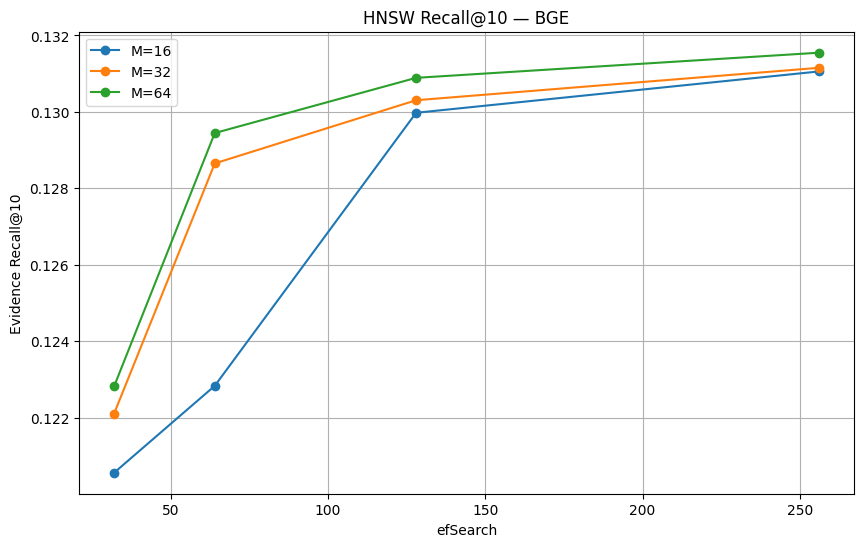

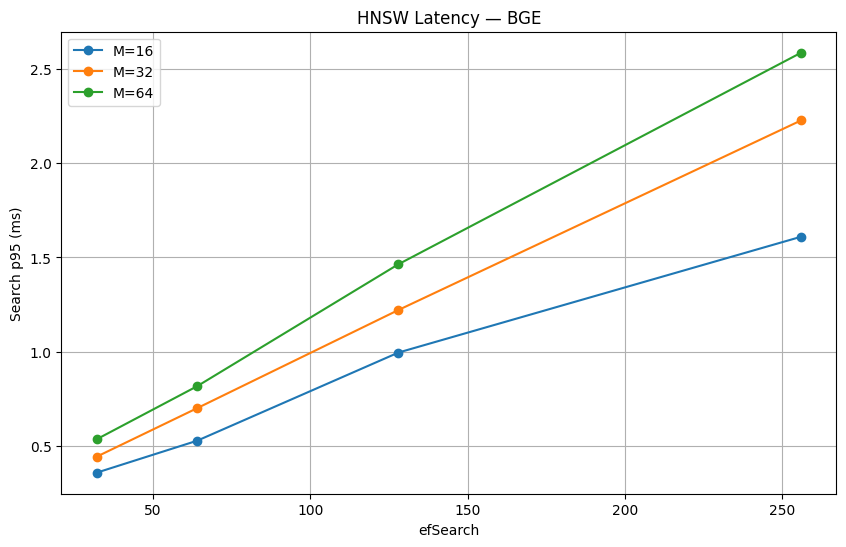

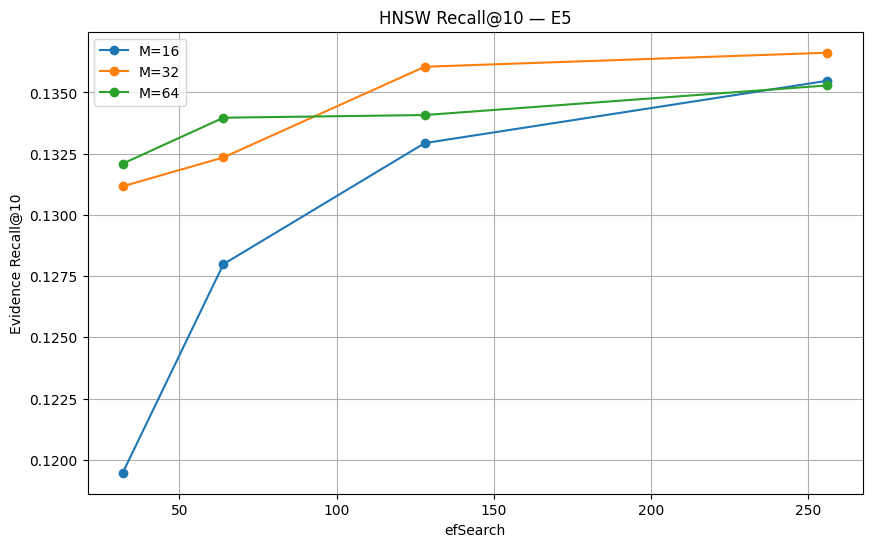

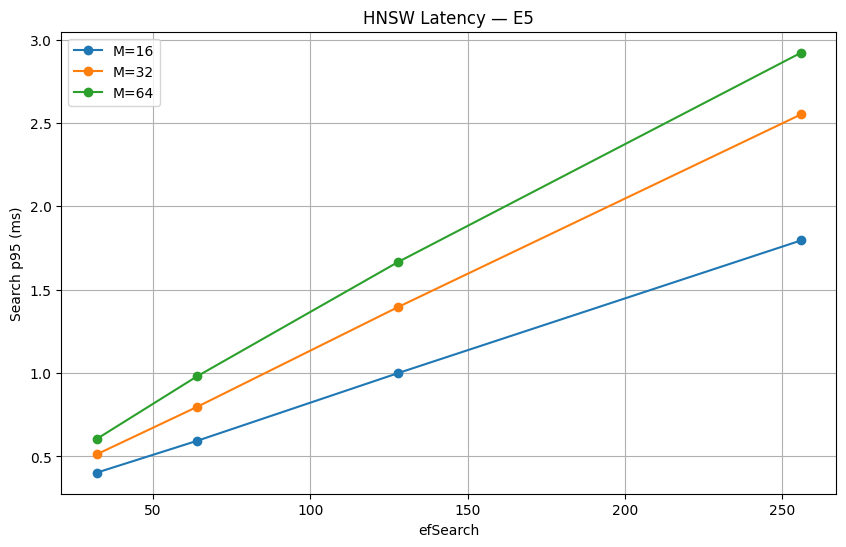

In [20]:
import matplotlib.pyplot as plt

for model_key in MODELS:

    subset = hnsw_summary_df[
        hnsw_summary_df["model"]
        == model_key
    ]

    plt.figure(
        figsize=(10, 6)
    )

    for M in HNSW_M_VALUES:

        part = subset[
            subset["M"] == M
        ].sort_values(
            "efSearch"
        )

        plt.plot(
            part["efSearch"],
            part["Recall@10"],
            marker="o",
            label=f"M={M}",
        )

    plt.xlabel("efSearch")
    plt.ylabel("Evidence Recall@10")
    plt.title(
        f"HNSW Recall@10 — {model_key.upper()}"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(
        figsize=(10, 6)
    )

    for M in HNSW_M_VALUES:

        part = subset[
            subset["M"] == M
        ].sort_values(
            "efSearch"
        )

        plt.plot(
            part["efSearch"],
            part["search_p95_ms"],
            marker="o",
            label=f"M={M}",
        )

    plt.xlabel("efSearch")
    plt.ylabel("Search p95 (ms)")
    plt.title(
        f"HNSW Latency — {model_key.upper()}"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

# 21. IVF parameter analysis

This shows how:

```text
nlist
nprobe
```

change the quality/latency trade-off.

Conceptually:

```text
nlist
  ↓
how finely corpus is partitioned

nprobe
  ↓
how many partitions are searched
```

Increasing `nprobe` generally increases search effort and can improve ANN Recall.

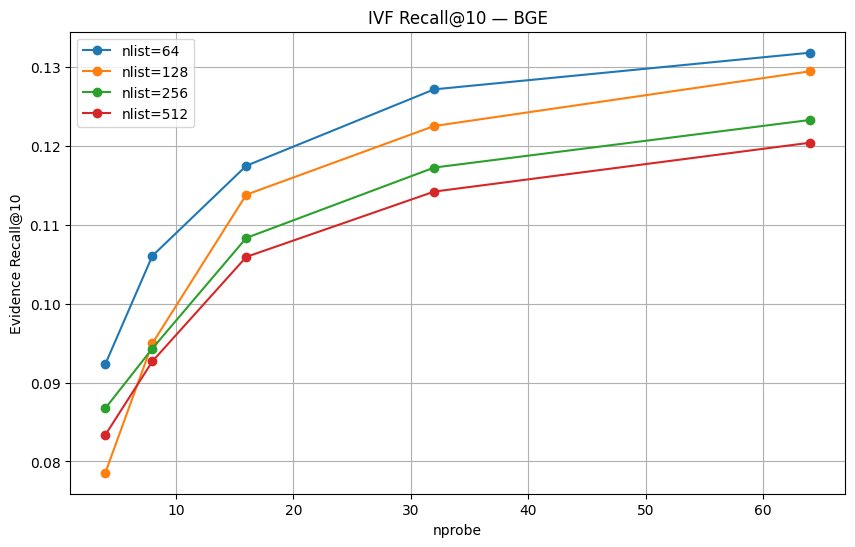

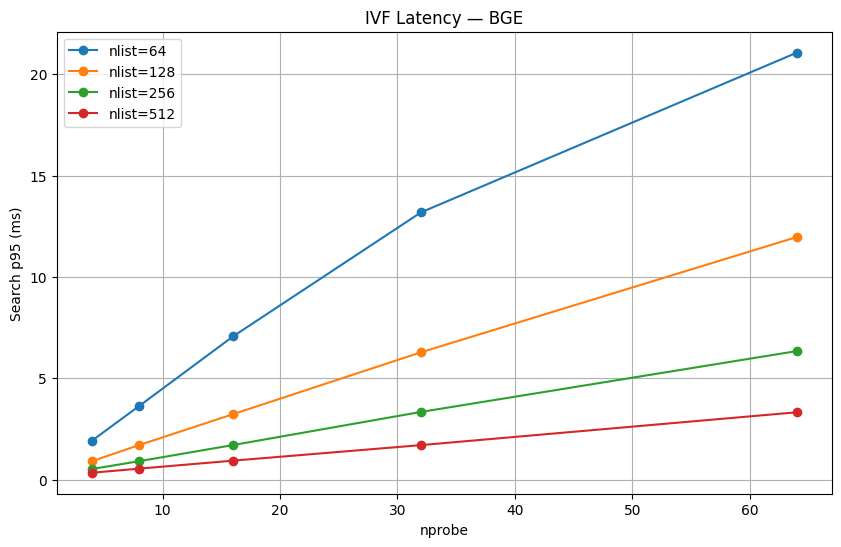

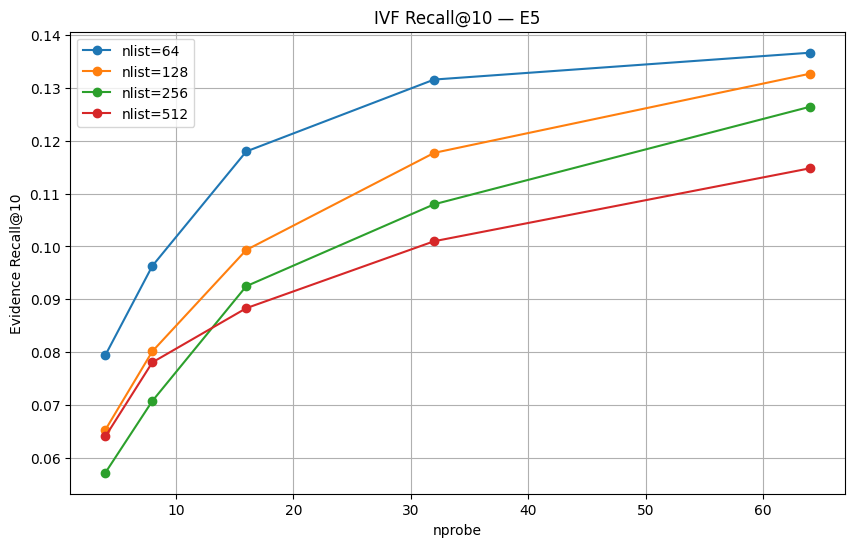

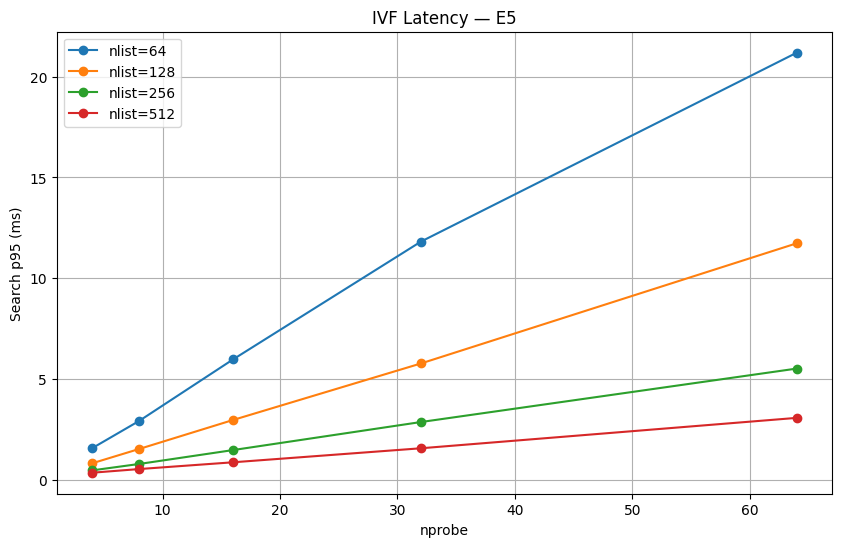

In [21]:
for model_key in MODELS:

    subset = ivf_summary_df[
        ivf_summary_df["model"]
        == model_key
    ]

    plt.figure(
        figsize=(10, 6)
    )

    for nlist in IVF_NLIST_VALUES:

        part = subset[
            subset["nlist"] == nlist
        ].sort_values(
            "nprobe"
        )

        plt.plot(
            part["nprobe"],
            part["Recall@10"],
            marker="o",
            label=f"nlist={nlist}",
        )

    plt.xlabel("nprobe")
    plt.ylabel("Evidence Recall@10")
    plt.title(
        f"IVF Recall@10 — {model_key.upper()}"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(
        figsize=(10, 6)
    )

    for nlist in IVF_NLIST_VALUES:

        part = subset[
            subset["nlist"] == nlist
        ].sort_values(
            "nprobe"
        )

        plt.plot(
            part["nprobe"],
            part["search_p95_ms"],
            marker="o",
            label=f"nlist={nlist}",
        )

    plt.xlabel("nprobe")
    plt.ylabel("Search p95 (ms)")
    plt.title(
        f"IVF Latency — {model_key.upper()}"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

# 22. IVF-PQ parameter analysis

This evaluates the compressed ANN system.

The key comparison is:

```text
quality
vs
latency
vs
compression
```

The PQ parameters are fixed in this experiment:

```text
pq_m=48
pq_bits=8
```

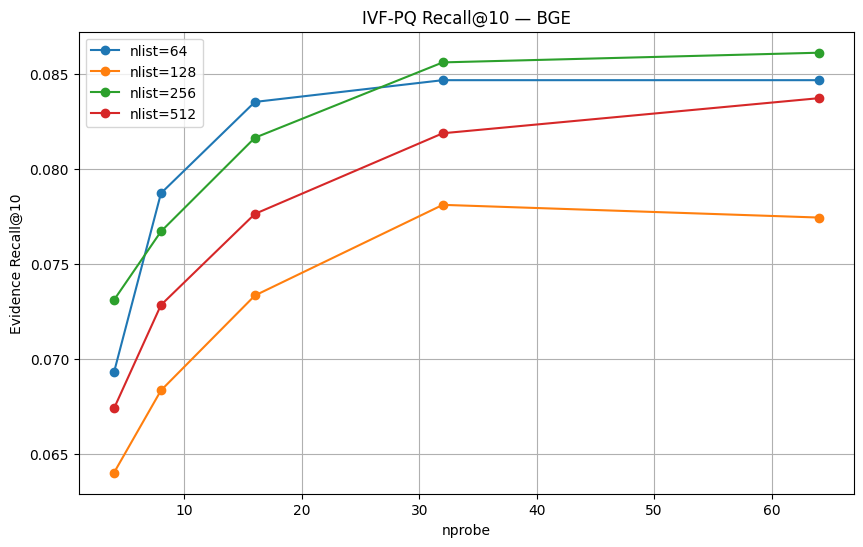

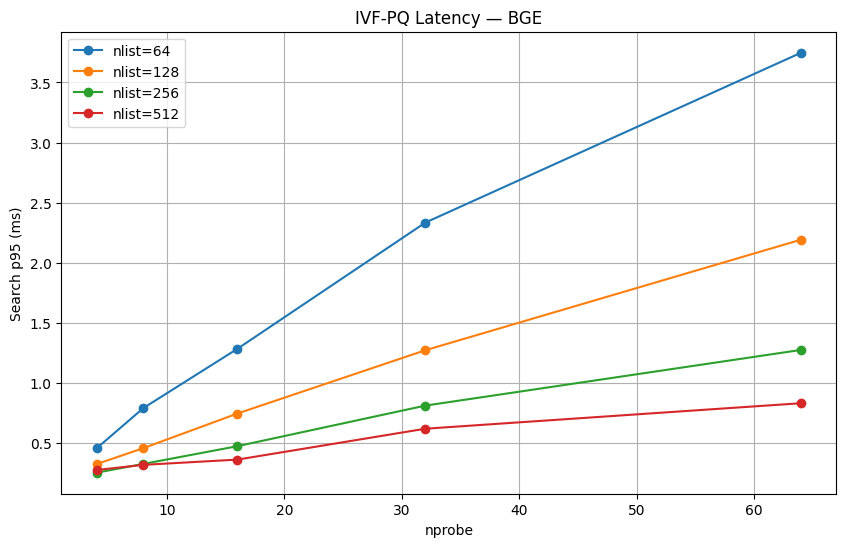

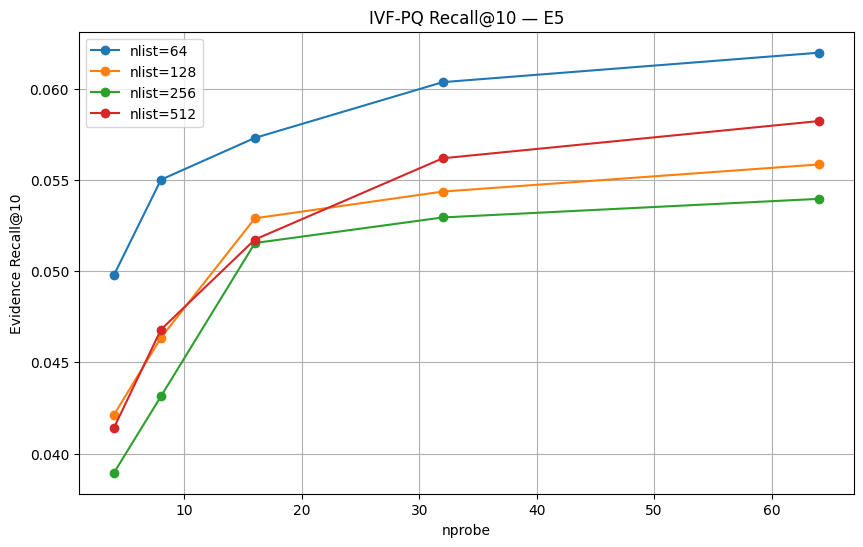

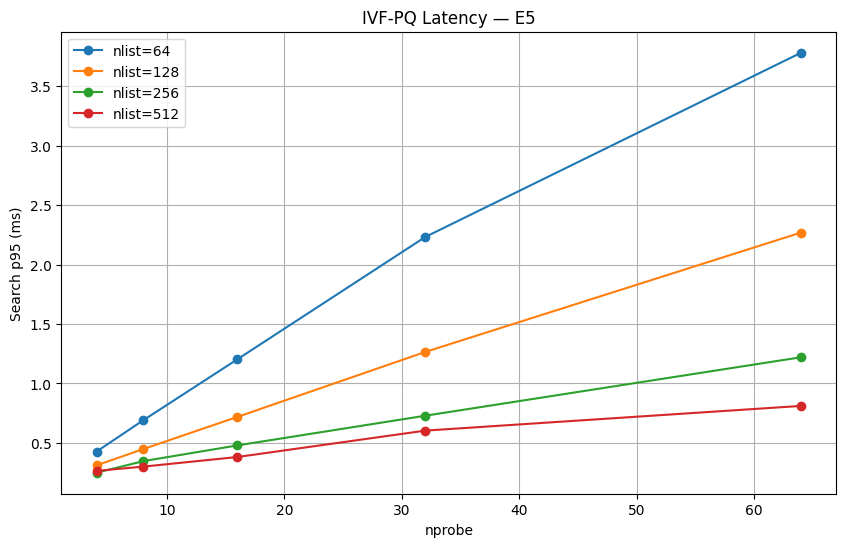

In [22]:
for model_key in MODELS:

    subset = ivfpq_summary_df[
        ivfpq_summary_df["model"]
        == model_key
    ]

    plt.figure(
        figsize=(10, 6)
    )

    for nlist in IVFPQ_NLIST_VALUES:

        part = subset[
            subset["nlist"] == nlist
        ].sort_values(
            "nprobe"
        )

        plt.plot(
            part["nprobe"],
            part["Recall@10"],
            marker="o",
            label=f"nlist={nlist}",
        )

    plt.xlabel("nprobe")
    plt.ylabel("Evidence Recall@10")
    plt.title(
        f"IVF-PQ Recall@10 — {model_key.upper()}"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(
        figsize=(10, 6)
    )

    for nlist in IVFPQ_NLIST_VALUES:

        part = subset[
            subset["nlist"] == nlist
        ].sort_values(
            "nprobe"
        )

        plt.plot(
            part["nprobe"],
            part["search_p95_ms"],
            marker="o",
            label=f"nlist={nlist}",
        )

    plt.xlabel("nprobe")
    plt.ylabel("Search p95 (ms)")
    plt.title(
        f"IVF-PQ Latency — {model_key.upper()}"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

# 23. Embedding cost

FAISS search latency and Transformer query encoding latency are different things.

For an online system:

```text
query
 ↓
embedding model
 ↓
FAISS search
```

so the eventual end-to-end retrieval latency includes both.

Corpus encoding is normally offline and should therefore be reported separately.

In [23]:
embedding_rows = []

for model_key, data in EMBED_CACHE.items():

    embedding_rows.append({
        "model": model_key,
        "model_name": MODELS[
            model_key
        ]["name"],
        "dimension": data[
            "dimension"
        ],
        "corpus_encode_sec": data[
            "corpus_encode_sec"
        ],
        "query_encode_sec": data[
            "query_encode_sec"
        ],
        "query_encode_ms_per_query": (
            data["query_encode_sec"]
            * 1000
            / len(queries)
            if data[
                "query_encode_sec"
            ] > 0
            else np.nan
        ),
        "corpus_cached": data[
            "corpus_cached"
        ],
        "query_cached": data[
            "query_cached"
        ],
    })

embedding_cost_df = pd.DataFrame(
    embedding_rows
)

display(
    embedding_cost_df
)

embedding_cost_df.to_csv(
    RESULT_DIR
    / "EMBEDDING_COSTS.csv",
    index=False,
)

,model,model_name,dimension,corpus_encode_sec,query_encode_sec,query_encode_ms_per_query,corpus_cached,query_cached
0,bge,BAAI/bge-base-en-v1.5,768,463.682365,0.744115,0.568027,False,False
1,e5,intfloat/e5-base-v2,768,483.339761,0.596496,0.455341,False,False


# 24. Compare against the existing BM25 baseline

Previously measured BM25 reference:

```text
Recall@10     = 0.0765
Precision@10  = 0.0152
F1@10         = 0.0236
nDCG@10       = 0.0524
MRR           = 0.0644

Mean latency  = 271.50 ms
P95 latency   = 477.73 ms
```

This notebook does not rerun BM25. Those numbers are the frozen Baseline 1 reference.

The dense systems can now be compared against it.

In [24]:
# ============================================================
# 24. BM25 vs best dense systems
# ============================================================

BM25_BASELINE = {
    "model": "BM25",
    "index": "BM25",
    "recall@10": 0.0765,
    "precision@10": 0.0152,
    "f1@10": 0.0236,
    "ndcg@10": 0.0524,
    "mrr": 0.0644,
    "mean_latency_ms": 271.50,
    "p95_latency_ms": 477.73,
}

best_dense = (
    all_results_df
    .dropna(
        subset=["recall@10"]
    )
    .sort_values(
        "recall@10",
        ascending=False,
    )
    .head(10)
)

comparison = best_dense[
    [
        "model",
        "index",
        "method",
        "precision@10",
        "recall@10",
        "f1@10",
        "ndcg@10",
        "mrr",
        "map",
        "search_mean_ms",
        "search_p95_ms",
    ]
].copy()

print("BM25 frozen reference:")
print(BM25_BASELINE)

print("\nBest dense configurations:")
display(comparison)

BM25 frozen reference:
{'model': 'BM25', 'index': 'BM25', 'recall@10': 0.0765, 'precision@10': 0.0152, 'f1@10': 0.0236, 'ndcg@10': 0.0524, 'mrr': 0.0644, 'mean_latency_ms': 271.5, 'p95_latency_ms': 477.73}

Best dense configurations:


,model,index,method,precision@10,recall@10,f1@10,ndcg@10,mrr,map,search_mean_ms,search_p95_ms
38,e5,FlatIP,FlatIP,0.024122,0.136621,0.038641,0.097536,0.110904,0.078475,21.601031,22.975894
44,e5,IVF_nlist64_nprobe64,IVF-Flat,0.024122,0.136621,0.038641,0.097536,0.110904,0.078475,20.479497,21.187765
50,e5,HNSW_M32_efSearch256,HNSW,0.024122,0.136621,0.038641,0.097575,0.111025,0.078542,2.086962,2.551268
54,e5,HNSW_M32_efSearch128,HNSW,0.024122,0.136048,0.038611,0.096998,0.110440,0.077981,1.148454,1.397113
25,e5,HNSW_M16_efSearch256,HNSW,0.023969,0.135476,0.038375,0.096987,0.110665,0.078137,1.523699,1.795454
72,e5,HNSW_M64_efSearch256,HNSW,0.023817,0.135285,0.038175,0.096460,0.109961,0.077530,2.380567,2.921017
59,e5,HNSW_M64_efSearch128,HNSW,0.023664,0.134076,0.037901,0.095287,0.108408,0.076588,1.329205,1.667317
98,e5,HNSW_M64_efSearch64,HNSW,0.023511,0.133967,0.037745,0.094372,0.106494,0.075626,0.762842,0.980873
70,e5,HNSW_M16_efSearch128,HNSW,0.023664,0.132930,0.037801,0.095046,0.108598,0.076461,0.830612,1.000595
87,e5,IVF_nlist128_nprobe64,IVF-Flat,0.023435,0.132651,0.037523,0.094687,0.107985,0.075910,10.829684,11.728469


# 25. Final benchmark artifacts

The important files are:

```text
ALL_EXPERIMENTS.csv
HNSW_FULL_SWEEP.csv
IVF_FULL_SWEEP.csv
IVFPQ_FULL_SWEEP.csv
EMBEDDING_COSTS.csv
```

plus:

```text
per-query CSV files
per-experiment JSON summaries
```

For GitHub, commit the notebook and compact summary files.

Avoid committing large embedding/index binaries unless Git LFS or an artifact repository is deliberately used.

In [25]:
# ============================================================
# 25. Artifact inventory
# ============================================================

artifact_rows = []

for p in WORK_DIR.rglob("*"):

    if p.is_file():

        artifact_rows.append({
            "path": str(
                p.relative_to(
                    WORK_DIR
                )
            ),
            "size_mb": (
                p.stat().st_size
                / 1024**2
            ),
        })

artifact_inventory = (
    pd.DataFrame(
        artifact_rows
    )
    .sort_values(
        "size_mb",
        ascending=False,
    )
)

display(
    artifact_inventory.head(100)
)

print(
    "\nTotal generated size:",
    f"{artifact_inventory['size_mb'].sum():.2f} MB"
)

,path,size_mb
219,embeddings/e5/corpus.npy,238.916138
217,embeddings/bge/corpus.npy,238.916138
220,embeddings/e5/queries_test.npy,3.838013
218,embeddings/bge/queries_test.npy,3.838013
86,results/bge_IVFPQ_nlist512_nprobe64.csv,0.377988
...,...,...
77,results/e5_IVF_nlist512_nprobe8.csv,0.357065
135,results/e5_IVF_nlist64_nprobe4.csv,0.356736
103,results/e5_IVFPQ_nlist512_nprobe8.csv,0.355811
55,results/e5_IVF_nlist128_nprobe4.csv,0.354238



Total generated size: 524.46 MB
